# 07 - LSTM Model (Daily Walk-Forward)

- Daily feature sequences (60-day lookback), same data as tree models
- 3-class moneyness target (ATM/OTM5/OTM10)
- Walk-forward validation, annual retraining (2014-2025)
- Separate train/val/test per fold
- Plain CrossEntropyLoss
- Bidirectional LSTM with temporal attention, 31 features incl. IV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']
SEQ_LENGTH = 60

print(f"Device: {device}")

Device: mps


## 1. Load Data and Add IV Features

In [2]:
data = pd.read_parquet(PROCESSED / 'daily_modeling_data.parquet')
data['date'] = pd.to_datetime(data['date'])

options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
calls = options[(options['call_put'] == 'CALL') & (options['symbol'].isin(UNIVERSE))].copy()
calls['trade_date'] = pd.to_datetime(calls['trade_date'])

atm = calls[(calls['delta'] >= 0.35) & (calls['delta'] <= 0.65)].copy()

daily_iv = atm.groupby(['symbol', 'trade_date']).agg(
    iv_mean=('implied_vol', 'mean'),
    iv_std=('implied_vol', 'std'),
).reset_index()

data = data.merge(daily_iv, left_on=['symbol', 'date'], right_on=['symbol', 'trade_date'], how='left')
data = data.drop(columns=['trade_date'], errors='ignore')

data = data.sort_values(['symbol', 'date'])
data['iv_mean'] = data.groupby('symbol')['iv_mean'].transform(lambda x: x.ffill())
data['iv_std'] = data.groupby('symbol')['iv_std'].transform(lambda x: x.ffill())

data['iv_rank'] = data.groupby('symbol')['iv_mean'].transform(
    lambda x: x.rolling(252, min_periods=60).apply(
        lambda w: (w.iloc[-1] - w.min()) / (w.max() - w.min()) if w.max() != w.min() else 0.5
    )
)
data['iv_change'] = data.groupby('symbol')['iv_mean'].pct_change(21)

print(f"Data with IV: {data.shape}")
print(f"IV coverage: iv_mean={data['iv_mean'].notna().mean():.1%}, iv_rank={data['iv_rank'].notna().mean():.1%}")

Data with IV: (29273, 38)
IV coverage: iv_mean=99.5%, iv_rank=97.5%


In [3]:
exclude = ['symbol', 'date', 'year_month', 'best_moneyness', 'best_return', 'label_3', 'year']
feature_cols = [c for c in data.columns if c not in exclude]

# Fill missing
data[feature_cols] = data.groupby('symbol')[feature_cols].transform(lambda x: x.ffill())
data[feature_cols] = data[feature_cols].fillna(0)

data['year'] = data['date'].dt.year

print(f"Features: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")
print(f"Years: {sorted(data['year'].unique())}")
print(f"Total rows: {len(data):,}")
print(f"\nLabel distribution:")
print(data['label_3'].value_counts().sort_index().to_string())

Features: 31
Feature list: ['daily_return', 'vol_5d', 'vol_21d', 'vol_63d', 'mom_5d', 'mom_21d', 'mom_63d', 'price_to_sma21', 'price_to_sma50', 'price_to_sma200', 'sma21_above_sma50', 'sma50_above_sma200', 'drawdown_63d', 'drawdown_252d', 'volume_ratio', 'rsi_14', 'bb_width', 'high_vol_regime', 'gross_margin', 'operating_margin', 'net_margin', 'revenue_growth_yoy', 'earnings_growth_yoy', 'debt_to_equity', 'cash_ratio', 'roe', 'roa', 'iv_mean', 'iv_std', 'iv_rank', 'iv_change']
Years: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Total rows: 29,273

Label distribution:
label_3
0    18152
1     5005
2     6116


## 2. Sequence Creation Functions

In [4]:
def create_sequences(subset_data, feature_cols, seq_length=60):
    """Sliding window: each daily row becomes a sample with seq_length lookback."""
    X_list, y_list, date_list = [], [], []
    for sym in subset_data['symbol'].unique():
        sym_data = subset_data[subset_data['symbol'] == sym].sort_values('date').reset_index(drop=True)
        features = sym_data[feature_cols].values
        labels = sym_data['label_3'].values
        dates = sym_data['date'].values
        for i in range(seq_length, len(sym_data)):
            X_list.append(features[i - seq_length:i])
            y_list.append(labels[i])
            date_list.append(dates[i])
    if len(X_list) == 0:
        return np.array([]).reshape(0, seq_length, len(feature_cols)), np.array([]), np.array([])
    return np.array(X_list), np.array(y_list), np.array(date_list)


def create_sequences_with_context(target_data, context_data, feature_cols, seq_length=60):
    """Same as above but prepends context rows so early-in-year rows get full lookback."""
    X_list, y_list, date_list = [], [], []
    for sym in target_data['symbol'].unique():
        ctx = context_data[context_data['symbol'] == sym].sort_values('date').tail(seq_length)
        tgt = target_data[target_data['symbol'] == sym].sort_values('date')
        combined = pd.concat([ctx, tgt]).sort_values('date').reset_index(drop=True)
        features = combined[feature_cols].values
        labels = combined['label_3'].values
        dates = combined['date'].values
        ctx_len = len(ctx)
        for i in range(max(seq_length, ctx_len), len(combined)):
            X_list.append(features[i - seq_length:i])
            y_list.append(labels[i])
            date_list.append(dates[i])
    if len(X_list) == 0:
        return np.array([]).reshape(0, seq_length, len(feature_cols)), np.array([]), np.array([])
    return np.array(X_list), np.array(y_list), np.array(date_list)

X_test_seq, y_test_seq, _ = create_sequences(data[data['year'] <= 2010], feature_cols, SEQ_LENGTH)
print(f"Test sequence creation: {X_test_seq.shape}")

Test sequence creation: (935, 60, 31)


## 3. LSTM with Temporal Attention

In [5]:
class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.3, bidirectional=True):
        super().__init__()
        self.directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_out_size = hidden_size * self.directions

        # Temporal attention
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_size, lstm_out_size // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_size // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_out_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        return self.classifier(context)

n_feat = len(feature_cols)
model_test = AttentionLSTM(n_feat, hidden_size=128, num_layers=2, num_classes=3, dropout=0.3)
n_params = sum(p.numel() for p in model_test.parameters())
print(f"AttentionLSTM: {n_params:,} parameters (hidden=128, layers=2, bidirectional)")
del model_test

AttentionLSTM: 626,948 parameters (hidden=128, layers=2, bidirectional)


## 4. Training Function

In [6]:
def train_lstm_fold(X_train, y_train, X_val, y_val, input_size, num_classes=3,
                    hidden_size=128, num_layers=2, dropout=0.3,
                    lr=1e-3, epochs=80, patience=10, batch_size=256):

    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_ds = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = AttentionLSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, num_classes=num_classes,
                          dropout=dropout).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1, best_state, wait = 0, None, 0
    history = {'train_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))

        model.eval()
        preds = []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())

        val_f1 = f1_score(y_val, preds, average='macro')
        history['val_f1'].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, best_f1, history

print("Training function defined")

Training function defined


## 5. Walk-Forward Validation

In [7]:
test_years = [y for y in sorted(data['year'].unique()) if y >= 2014]
print(f"Walk-forward test years: {test_years}\n")

all_preds, all_true, all_dates = [], [], []
fold_results = []

for test_year in test_years:
    print(f"{'='*60}")
    print(f"Test year: {test_year}")

    train_data = data[data['year'] < test_year]
    test_data = data[data['year'] == test_year]
    if len(train_data) < 500:
        print(f"  Skipping, insufficient training data ({len(train_data)} rows)")
        continue

    val_year = test_year - 1
    pure_train_data = train_data[train_data['year'] < val_year]
    val_data = train_data[train_data['year'] == val_year]

    if len(pure_train_data) < 500:
        train_sorted = train_data.sort_values('date')
        split_idx = int(len(train_sorted) * 0.8)
        pure_train_data = train_sorted.iloc[:split_idx]
        val_data = train_sorted.iloc[split_idx:]

    X_train, y_train, _ = create_sequences(pure_train_data, feature_cols, SEQ_LENGTH)
    X_val, y_val, _ = create_sequences_with_context(val_data, pure_train_data, feature_cols, SEQ_LENGTH)
    X_test, y_test, dates_test = create_sequences_with_context(test_data, train_data, feature_cols, SEQ_LENGTH)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        print(f"  Skipping, empty sequences (train={len(X_train)}, val={len(X_val)}, test={len(X_test)})")
        continue

    n_tr, seq_len, n_f = X_train.shape
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, n_f)).reshape(n_tr, seq_len, n_f)
    X_val = scaler.transform(X_val.reshape(-1, n_f)).reshape(len(X_val), seq_len, n_f)
    X_test = scaler.transform(X_test.reshape(-1, n_f)).reshape(len(X_test), seq_len, n_f)

    print(f"  train={len(X_train):,}, val={len(X_val):,}, test={len(X_test):,}")

    torch.manual_seed(SEED)
    model, val_f1, history = train_lstm_fold(
        X_train, y_train, X_val, y_val,
        input_size=n_f, epochs=80, patience=10, batch_size=256
    )

    model.eval()
    test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
    preds = np.array(preds)

    fold_acc = accuracy_score(y_test, preds)
    fold_f1 = f1_score(y_test, preds, average='macro')

    all_preds.extend(preds)
    all_true.extend(y_test)
    all_dates.extend(dates_test)
    fold_results.append({
        'year': test_year, 'train': len(X_train), 'val': len(X_val),
        'test': len(X_test), 'acc': fold_acc, 'f1': fold_f1,
        'val_f1': val_f1, 'epochs': len(history['train_loss'])
    })
    print(f"  Acc={fold_acc:.4f}, F1={fold_f1:.4f} (val_f1={val_f1:.4f}, epochs={len(history['train_loss'])})")

all_preds, all_true = np.array(all_preds), np.array(all_true)
wf_acc = accuracy_score(all_true, all_preds)
wf_f1 = f1_score(all_true, all_preds, average='macro')
print(f"\n{'='*60}")
print(f"Overall Walk-Forward LSTM: Acc={wf_acc:.4f}, Macro F1={wf_f1:.4f}")

Walk-forward test years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Test year: 2014
  train=2,946, val=1,178, test=1,710


  Acc=0.5082, F1=0.4202 (val_f1=0.4387, epochs=11)
Test year: 2015
  train=4,124, val=1,710, test=2,023


  Acc=0.4558, F1=0.3472 (val_f1=0.4324, epochs=13)
Test year: 2016
  train=5,834, val=2,023, test=2,055


  Acc=0.4730, F1=0.3602 (val_f1=0.5804, epochs=16)
Test year: 2017


  train=7,857, val=2,055, test=2,037


...

  Acc=0.4391, F1=0.3517 (val_f1=0.3760, epochs=13)
Test year: 2024


  train=22,173, val=2,300, test=2,110


  Acc=0.4076, F1=0.3547 (val_f1=0.3805, epochs=17)
Test year: 2025


  train=24,473, val=2,110, test=2,090


  Acc=0.2727, F1=0.2430 (val_f1=0.3845, epochs=14)

Overall Walk-Forward LSTM: Acc=0.5445, Macro F1=0.4156


## 6. Results and Classification Report

              precision    recall  f1-score   support

         ATM       0.75      0.66      0.70     16556
        OTM5       0.17      0.26      0.20      3436
       OTM10       0.34      0.35      0.34      4557

    accuracy                           0.54     24549
   macro avg       0.42      0.42      0.42     24549
weighted avg       0.59      0.54      0.56     24549


Per-Year Walk-Forward Results:
 year  train  val  test      acc       f1   val_f1  epochs
 2014   2946 1178  1710 0.508187 0.420179 0.438715      11
 2015   4124 1710  2023 0.455759 0.347154 0.432372      13
 2016   5834 2023  2055 0.472993 0.360209 0.580406      16
 2017   7857 2055  2037 0.837015 0.618925 0.398578      11
 2018   9912 2037  1878 0.730032 0.548993 0.658336      20
 2019  11949 1878  1878 0.747071 0.553225 0.634155      16
 2020  13827 1878  2045 0.621516 0.564717 0.648350      16
 2021  15705 2045  2097 0.564616 0.367446 0.585235      16
 2022  17750 2097  2326 0.529235 0.283290 0.405787      

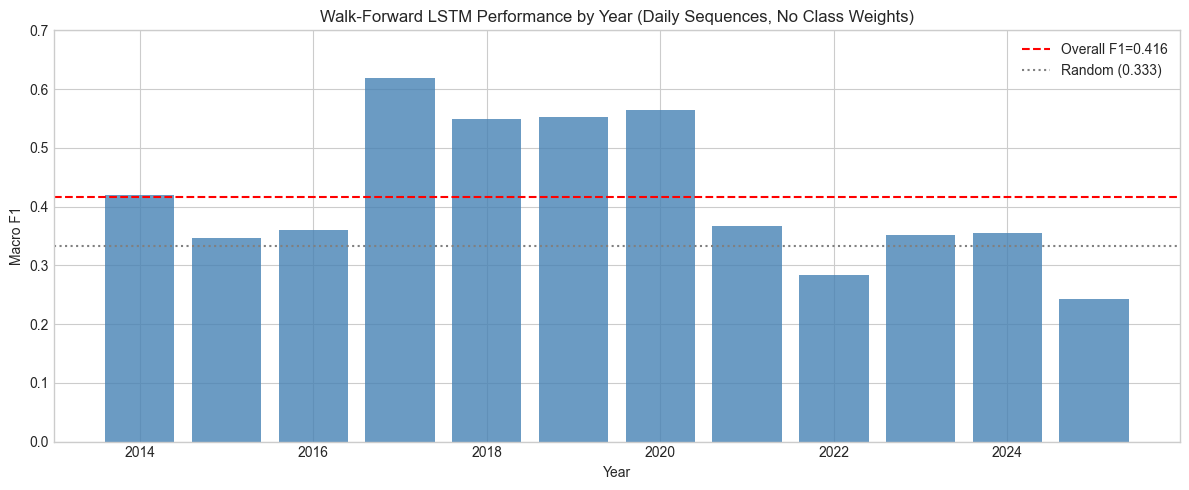

In [8]:
print(classification_report(all_true, all_preds, target_names=['ATM', 'OTM5', 'OTM10']))

# Per-year results table
fold_df = pd.DataFrame(fold_results)
print("\nPer-Year Walk-Forward Results:")
print(fold_df.to_string(index=False))

# Per-year F1 bar chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(fold_df['year'], fold_df['f1'], color='steelblue', alpha=0.8)
ax.axhline(y=wf_f1, color='red', linestyle='--', label=f'Overall F1={wf_f1:.3f}')
ax.axhline(y=1/3, color='gray', linestyle=':', label='Random (0.333)')
ax.set_xlabel('Year')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward LSTM Performance by Year (Daily Sequences, No Class Weights)')
ax.legend()
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.savefig('../reports/figures/lstm_walkforward_yearly_f1.png', dpi=150)
plt.show()

## 7. Confusion Matrix

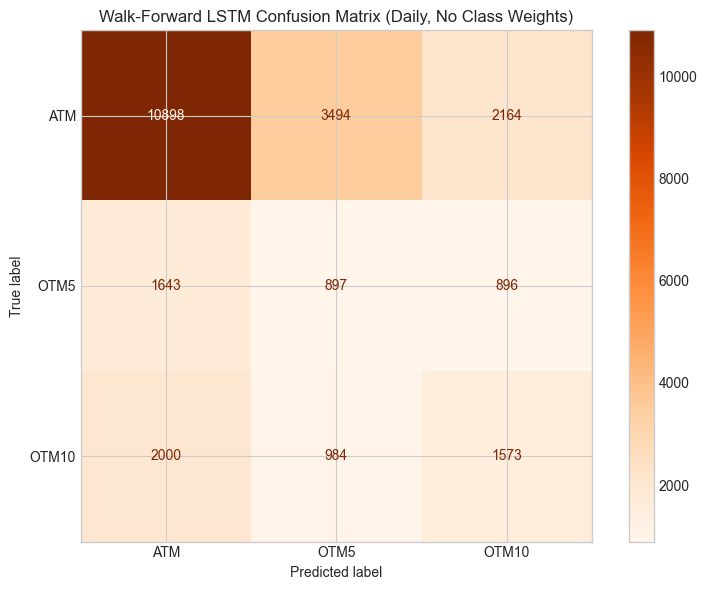

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['ATM', 'OTM5', 'OTM10'])
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Walk-Forward LSTM Confusion Matrix (Daily, No Class Weights)')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_walkforward_confusion_matrix.png', dpi=150)
plt.show()

## 8. Comparison with LightGBM Walk-Forward

Walk-Forward Model Comparison:
                Model  Accuracy  Macro F1
    LSTM Walk-Forward  0.544544  0.415614
LightGBM Walk-Forward  0.637965  0.458762


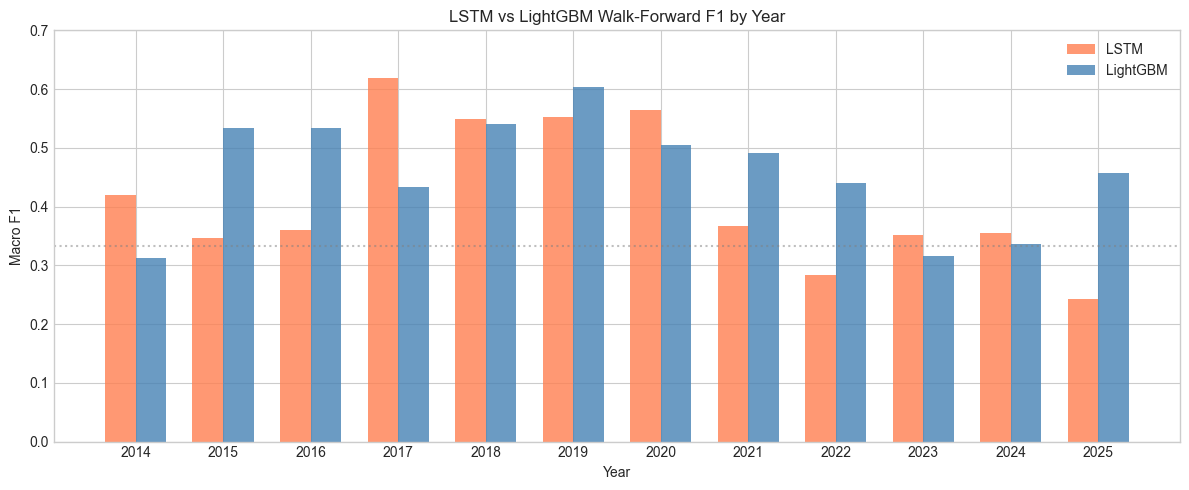

In [10]:
try:
    lgbm_wf = pd.read_csv(PROCESSED / 'walkforward_results.csv')
    lgbm_overall_f1 = lgbm_wf['f1'].mean()
    lgbm_overall_acc = lgbm_wf['acc'].mean()
    has_lgbm = True
except:
    has_lgbm = False

comparison = pd.DataFrame({
    'Model': ['LSTM Walk-Forward'],
    'Accuracy': [wf_acc],
    'Macro F1': [wf_f1]
})
if has_lgbm:
    comparison = pd.concat([comparison, pd.DataFrame({
        'Model': ['LightGBM Walk-Forward'],
        'Accuracy': [lgbm_overall_acc],
        'Macro F1': [lgbm_overall_f1]
    })], ignore_index=True)

print("Walk-Forward Model Comparison:")
print(comparison.to_string(index=False))

if has_lgbm:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(fold_df))
    w = 0.35
    ax.bar(x - w/2, fold_df['f1'].values, w, label='LSTM', color='coral', alpha=0.8)
    lgbm_years = lgbm_wf[lgbm_wf['year'].isin(fold_df['year'].values)]
    if len(lgbm_years) == len(fold_df):
        ax.bar(x + w/2, lgbm_years['f1'].values, w, label='LightGBM', color='steelblue', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(fold_df['year'].values)
    ax.set_xlabel('Year')
    ax.set_ylabel('Macro F1')
    ax.set_title('LSTM vs LightGBM Walk-Forward F1 by Year')
    ax.legend()
    ax.set_ylim(0, 0.7)
    ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.savefig('../reports/figures/lstm_vs_lgbm_walkforward.png', dpi=150)
    plt.show()

## 9. Save Model and Results

In [11]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': n_feat, 'hidden_size': 128, 'num_layers': 2,
    'num_classes': 3, 'seq_length': SEQ_LENGTH,
    'feature_cols': feature_cols,
    'scaler_mean': scaler.mean_, 'scaler_scale': scaler.scale_,
    'approach': 'walk-forward, daily sequences, no class weights, IV features, 31 features',
}, MODELS / 'lstm_walkforward_daily.pt')

fold_df.to_csv(PROCESSED / 'lstm_walkforward_results.csv', index=False)

all_results = pd.DataFrame({
    'Model': ['LSTM walk-forward (daily)'],
    'Accuracy': [wf_acc],
    'Macro F1': [wf_f1]
})
try:
    prev = pd.read_csv(PROCESSED / 'all_model_results.csv')
    prev = prev[~prev['Model'].str.contains('LSTM', case=False)]
    all_results = pd.concat([prev, all_results], ignore_index=True)
except:
    pass
all_results.to_csv(PROCESSED / 'all_model_results.csv', index=False)

print("Model saved: lstm_walkforward_daily.pt")
print(f"Walk-Forward LSTM: Acc={wf_acc:.4f}, Macro F1={wf_f1:.4f}")
print(f"\nAll model results:")
print(all_results.to_string(index=False))

Model saved: lstm_walkforward_daily.pt
Walk-Forward LSTM: Acc=0.5445, Macro F1=0.4156

All model results:
                           Model  Accuracy  Macro F1
           9-class RF (baseline)  0.372800  0.358100
          9-class XGB (baseline)  0.387100  0.355600
  6-class RF (tuned, time-split)  0.285000  0.226100
 6-class XGB (tuned, time-split)  0.240100  0.192800
6-class LGBM (tuned, time-split)  0.216400  0.176500
  6-class Two-Stage (time-split)  0.229600  0.166700
       LSTM walk-forward (daily)  0.544544  0.415614
